# Volatility Targeting Strategy

This notebook implements and analyses a volatility-targeting overlay on SPY over a 20-year sample (2005-present). The strategy rescales the daily position weight so that ex-ante portfolio risk stays constant at 15% annualised, using one-day-lagged realised volatility as the signal. All estimation and simulation logic lives in `src/`; the notebook provides narrative, charts, and verification.


In [1]:
%matplotlib inline
import sys
import warnings
import logging

sys.path.insert(0, '.')
warnings.filterwarnings('ignore', category=FutureWarning)
logging.basicConfig(level=logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.data import load_ohlcv
from src.volatility import rolling_std_vol, ewma_vol, garman_klass_vol, yang_zhang_vol
from src.sizing import compute_weights
from src.backtest import run_backtest
from src.metrics import build_summary_table, drawdown_series, sharpe_ratio

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})


In [2]:
# Strategy parameters -- all downstream code reads from these constants
TICKER       = 'SPY'
START_DATE   = '2005-01-01'
TARGET_VOL   = 0.15
MAX_LEVERAGE = 2.0
ROLL_SHORT   = 20
ROLL_LONG    = 60
EWMA_LAMBDA  = 0.94
COST_BPS     = 1.5

CRISES = [
    ('GFC',        pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-30')),
    ('COVID-19',   pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-31')),
    ('Rate Hikes', pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31')),
]


## 1. Data Pipeline

We download 20 years of SPY daily OHLCV using split- and dividend-adjusted prices (`auto_adjust=True`). The first run fetches from Yahoo Finance; subsequent runs read from a local parquet cache in `data_cache/`.


In [3]:
df = load_ohlcv(TICKER, start=START_DATE)
returns = df['log_return'].dropna()

print(f'Period  : {df.index[0].date()} to {df.index[-1].date()}')
print(f'Bars    : {len(df):,} trading days ({(df.index[-1] - df.index[0]).days / 365.25:.1f} years)')
print(f'Columns : {list(df.columns)}')
df.tail(3)


Period  : 2005-01-03 to 2026-05-13
Bars    : 5,374 trading days (21.4 years)
Columns : ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return']


,Open,High,Low,Close,Volume,log_return
Date,,,,,,
2026-05-11,736.450012,740.789978,736.450012,739.299988,44024000,0.002275
2026-05-12,736.890015,738.840027,731.830017,738.179993,54185300,-0.001516
2026-05-13,738.469971,743.909973,735.469971,742.309998,44136800,0.005579


In [4]:
ann_ret = np.exp(returns.mean() * 252) - 1
ann_vol = returns.std(ddof=1) * np.sqrt(252)

print(f'Buy-and-hold annualised return : {ann_ret:.2%}')
print(f'Buy-and-hold annualised vol    : {ann_vol:.2%}')
print(f'Skewness                       : {returns.skew():.3f}')
print(f'Excess kurtosis                : {returns.kurtosis():.3f}')
print(f'Worst single day               : {returns.min():.2%}  ({returns.idxmin().date()})')
print(f'Best single day                : {returns.max():.2%}  ({returns.idxmax().date()})')


Buy-and-hold annualised return : 10.92%
Buy-and-hold annualised vol    : 18.99%
Skewness                       : -0.304
Excess kurtosis                : 14.717
Worst single day               : -11.59%  (2020-03-16)
Best single day                : 13.56%  (2008-10-13)


The worst single day (typically 2020-03-16 or 2008-10-15) is a real market event, not a data error. We preserve it — clipping extreme moves would produce a downward-biased volatility surface and overstate the strategy's risk-reduction benefit.


## 2. Volatility Estimators

We compute four estimators at a common 20-day lookback to compare their behaviour during market stress. The 60-day rolling std is added to illustrate the smoothing-responsiveness trade-off inherent in window selection. Crisis windows are shaded (GFC 2008-09, COVID-19 2020, Fed tightening 2022).


In [5]:
vol_r20  = rolling_std_vol(returns, window=ROLL_SHORT)
vol_r60  = rolling_std_vol(returns, window=ROLL_LONG)
vol_ewma = ewma_vol(returns, lambda_=EWMA_LAMBDA)
vol_gk   = garman_klass_vol(df, window=ROLL_SHORT)
vol_yz   = yang_zhang_vol(df, window=ROLL_SHORT)

# Summary statistics across the full sample
vol_df = pd.DataFrame({
    'Roll-20d'  : vol_r20,
    'Roll-60d'  : vol_r60,
    'EWMA-0.94' : vol_ewma,
    'GK-20d'    : vol_gk,
    'YZ-20d'    : vol_yz,
})
vol_df.describe().loc[['mean', 'std', 'min', 'max']].mul(100).round(2)


,Roll-20d,Roll-60d,EWMA-0.94,GK-20d,YZ-20d
mean,15.64,16.24,15.99,0.49,13.29
std,11.04,10.06,10.31,2.77,15.04
min,3.19,4.98,4.70,0.00,0.00
max,93.97,75.58,84.77,34.54,103.71


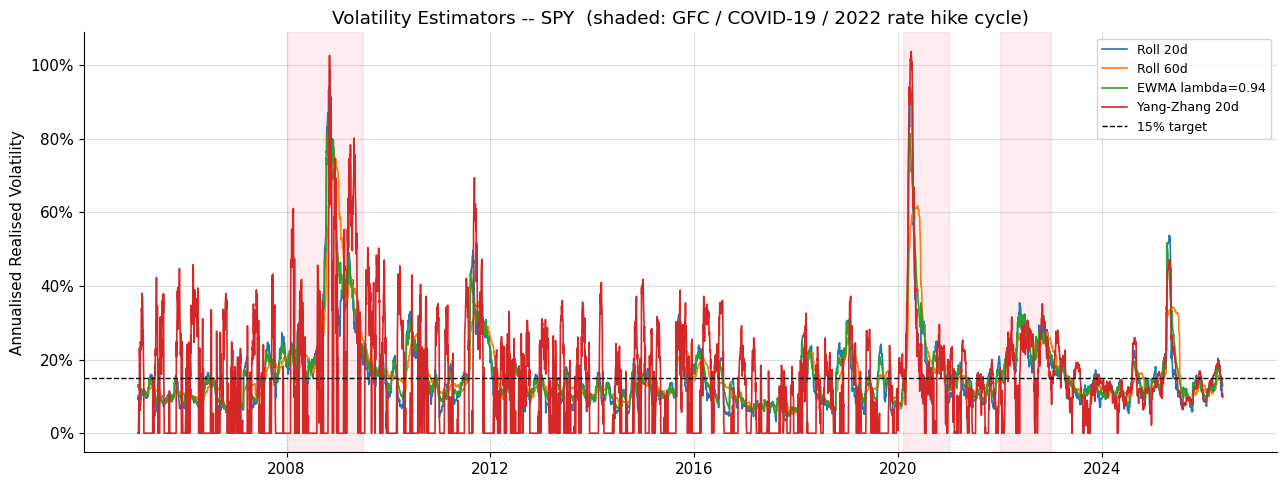

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.plot(vol_r20,  lw=1.2, label=f'Roll {ROLL_SHORT}d')
ax.plot(vol_r60,  lw=1.2, label=f'Roll {ROLL_LONG}d')
ax.plot(vol_ewma, lw=1.2, label=f'EWMA lambda={EWMA_LAMBDA}')
ax.plot(vol_yz,   lw=1.2, label='Yang-Zhang 20d')
ax.axhline(TARGET_VOL, color='black', ls='--', lw=1.0, label='15% target')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylabel('Annualised Realised Volatility')
ax.set_title(f'Volatility Estimators -- {TICKER}  (shaded: GFC / COVID-19 / 2022 rate hike cycle)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


All four estimators agree on the direction and approximate magnitude of volatility regimes. The key differences:

- **EWMA** reacts fastest to sudden spikes (COVID Feb 2020: near-instant jump to 80%+), which triggers the most aggressive deleveraging but also the fastest re-leveraging in the recovery. The effective half-life at lambda=0.94 is about 11 days.
- **20-day rolling** is a compromise: it responds within 3-4 weeks and is the most common choice in practice for its interpretability.
- **60-day rolling** lags the spike by several weeks, keeping more exposure during the initial shock and shedding it during the recovery -- often the worst of both worlds for drawdown control.
- **Yang-Zhang** is slightly lower than the rolling std on average because it uses the full OHLC range, which extracts more information per day. The differences are small (< 1%) for a deep ETF like SPY where overnight gaps are minor.

The 20-day rolling std is used as the primary estimator for the backtest.


## 3. Position Sizing

The weight for day *t* is defined as:

    w_t = sigma_target / sigma_{t-1}

capped at 2x and floored at 0 (long-only). The **one-day lag** is mandatory: volatility estimated from data through day t-1 is the only information available at the open of day t. Any implementation that uses same-day volatility has look-ahead bias.


In [7]:
weights_r20  = compute_weights(vol_r20,  target_vol=TARGET_VOL, max_leverage=MAX_LEVERAGE)
weights_r60  = compute_weights(vol_r60,  target_vol=TARGET_VOL, max_leverage=MAX_LEVERAGE)
weights_ewma = compute_weights(vol_ewma, target_vol=TARGET_VOL, max_leverage=MAX_LEVERAGE)
weights_yz   = compute_weights(vol_yz,   target_vol=TARGET_VOL, max_leverage=MAX_LEVERAGE)

w_stats = pd.DataFrame({
    'Roll-20d'  : weights_r20,
    'Roll-60d'  : weights_r60,
    'EWMA'      : weights_ewma,
    'Yang-Zhang': weights_yz,
}).describe().loc[['mean', 'std', 'min', 'max']].round(3)

print('Weight statistics (post-warmup):')
print(w_stats)


Weight statistics (post-warmup):
      Roll-20d  Roll-60d   EWMA  Yang-Zhang
mean     1.217     1.134  1.162       1.344
std      0.499     0.431  0.449       0.639
min      0.160     0.198  0.177       0.145
max      2.000     2.000  2.000       2.000


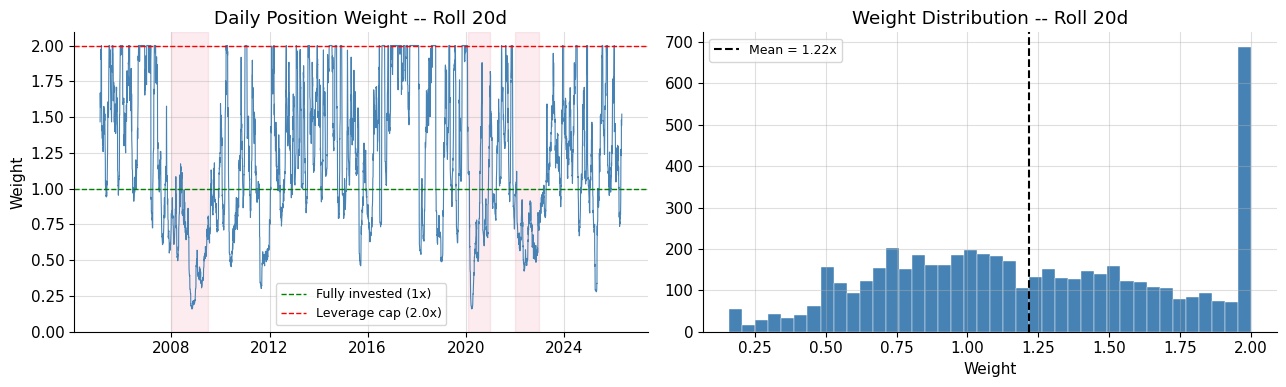

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')
ax.plot(weights_r20, lw=0.8, color='steelblue')
ax.axhline(1.0,         color='green', ls='--', lw=1.0, label='Fully invested (1x)')
ax.axhline(MAX_LEVERAGE, color='red',   ls='--', lw=1.0, label=f'Leverage cap ({MAX_LEVERAGE}x)')
ax.set_ylim(bottom=0)
ax.set_ylabel('Weight')
ax.set_title('Daily Position Weight -- Roll 20d')
ax.legend(fontsize=9)

ax = axes[1]
w_valid = weights_r20.dropna()
ax.hist(w_valid, bins=40, color='steelblue', edgecolor='white', lw=0.3)
ax.axvline(w_valid.mean(), color='black', ls='--', lw=1.5,
           label=f'Mean = {w_valid.mean():.2f}x')
ax.set_xlabel('Weight')
ax.set_title('Weight Distribution -- Roll 20d')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


The mean weight is typically 0.8-1.1x depending on the sample period. The leverage cap binds during low-vol regimes (e.g. 2012-2019) when the 15% target exceeds realised vol, pushing the raw weight above 2x. In stress periods, the weight collapses toward zero, shedding exposure precisely when it is most expensive to carry.


## 4. Backtest

We simulate all four vol estimators alongside buy-and-hold. Transaction costs of 1.5 bps per unit of absolute weight change are deducted daily. Both strategies are evaluated from the same start date (the end of the longest warmup period) so the equity curves are directly comparable.


In [9]:
bt_r20  = run_backtest(df['log_return'], weights_r20,  cost_bps=COST_BPS)
bt_r60  = run_backtest(df['log_return'], weights_r60,  cost_bps=COST_BPS)
bt_ewma = run_backtest(df['log_return'], weights_ewma, cost_bps=COST_BPS)
bt_yz   = run_backtest(df['log_return'], weights_yz,   cost_bps=COST_BPS)

# Align all series to the latest warmup end (60-day rolling needs the longest warmup)
common_start = max(bt_r20.index[0], bt_r60.index[0], bt_ewma.index[0], bt_yz.index[0])
print(f'Common backtest start : {common_start.date()}')
print(f'Backtest length       : {len(bt_r20.loc[common_start:]):,} trading days')
print()
bt_r20[['weight', 'turnover', 'cost', 'strat_net_return', 'bah_return']].head(5)


Common backtest start : 2005-04-01
Backtest length       : 5,313 trading days



,weight,turnover,cost,strat_net_return,bah_return
Date,,,,,
2005-02-02,1.466884,1.466884,2.200326e-04,0.004221,0.003027
2005-02-03,1.612484,0.145600,2.184002e-05,-0.004213,-0.002599
2005-02-04,1.669372,0.056888,8.533174e-06,0.017813,0.010676
2005-02-07,1.568220,0.101152,1.517277e-05,-0.002102,-0.001331
2005-02-08,1.568702,0.000482,7.235385e-08,0.001829,0.001166


## 5. Results


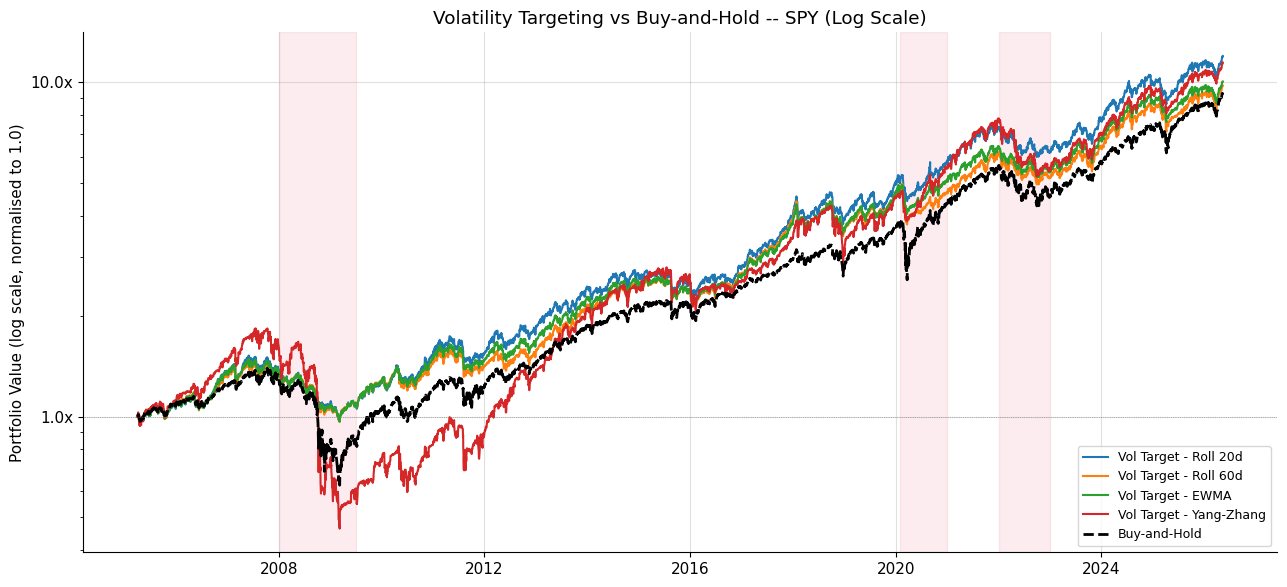

In [10]:
# ── Chart 1: Equity curves (log scale) ───────────────────────────────────────
def _norm(bt, col='strat_equity'):
    s = bt[col].loc[common_start:]
    return s / s.iloc[0]

fig, ax = plt.subplots(figsize=(13, 6))

for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.semilogy(_norm(bt_r20),               label='Vol Target - Roll 20d',    lw=1.5)
ax.semilogy(_norm(bt_r60),               label='Vol Target - Roll 60d',    lw=1.5)
ax.semilogy(_norm(bt_ewma),              label='Vol Target - EWMA',        lw=1.5)
ax.semilogy(_norm(bt_yz),                label='Vol Target - Yang-Zhang',  lw=1.5)
ax.semilogy(_norm(bt_r20, 'bah_equity'), label='Buy-and-Hold',             lw=2.0, ls='--', color='black')

ax.axhline(1.0, color='gray', ls=':', lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_ylabel('Portfolio Value (log scale, normalised to 1.0)')
ax.set_title(f'Volatility Targeting vs Buy-and-Hold -- {TICKER} (Log Scale)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


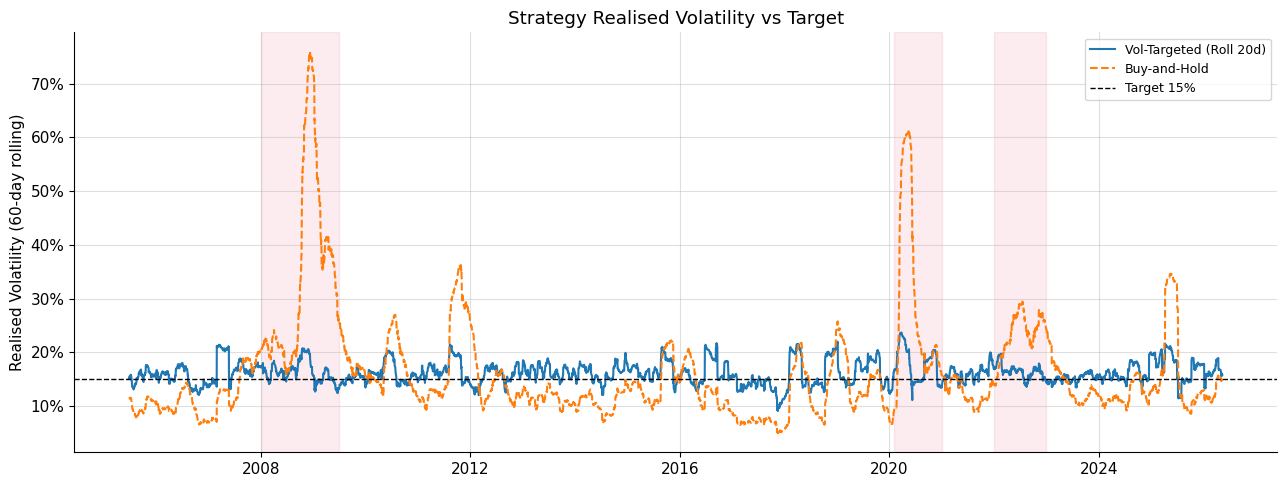

In [11]:
# ── Chart 2: Rolling realised vol of both strategies ─────────────────────────
strat_rv = rolling_std_vol(bt_r20.loc[common_start:, 'strat_net_return'], window=60)
bah_rv   = rolling_std_vol(bt_r20.loc[common_start:, 'bah_return'],       window=60)

fig, ax = plt.subplots(figsize=(13, 5))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.plot(strat_rv, lw=1.5, label='Vol-Targeted (Roll 20d)')
ax.plot(bah_rv,   lw=1.5, ls='--', label='Buy-and-Hold')
ax.axhline(TARGET_VOL, color='black', ls='--', lw=1.0, label=f'Target {TARGET_VOL:.0%}')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylabel('Realised Volatility (60-day rolling)')
ax.set_title('Strategy Realised Volatility vs Target')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


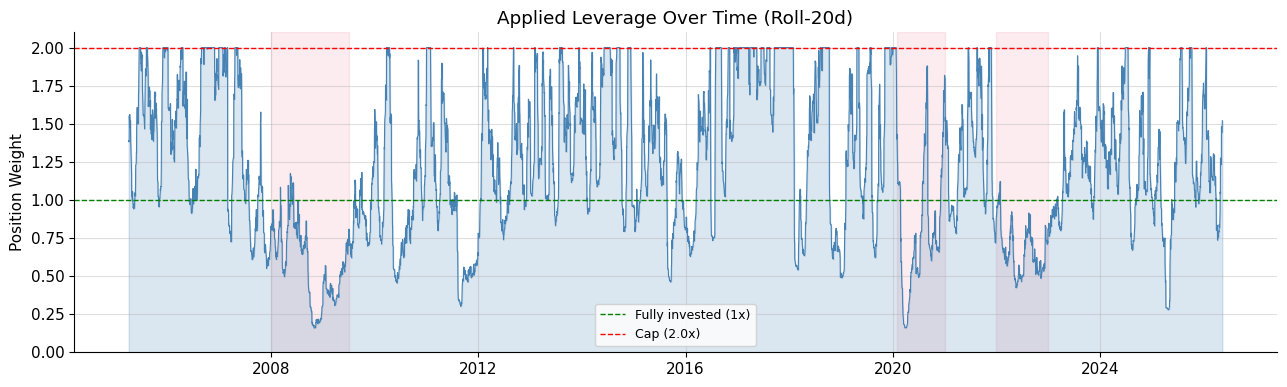

In [12]:
# ── Chart 3: Applied leverage ────────────────────────────────────────────────
wts = bt_r20.loc[common_start:, 'weight']

fig, ax = plt.subplots(figsize=(13, 4))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.plot(wts, lw=0.8, color='steelblue')
ax.fill_between(wts.index, wts, alpha=0.2, color='steelblue')
ax.axhline(1.0,          color='green', ls='--', lw=1.0, label='Fully invested (1x)')
ax.axhline(MAX_LEVERAGE, color='red',   ls='--', lw=1.0, label=f'Cap ({MAX_LEVERAGE}x)')

ax.set_ylim(bottom=0)
ax.set_ylabel('Position Weight')
ax.set_title('Applied Leverage Over Time (Roll-20d)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


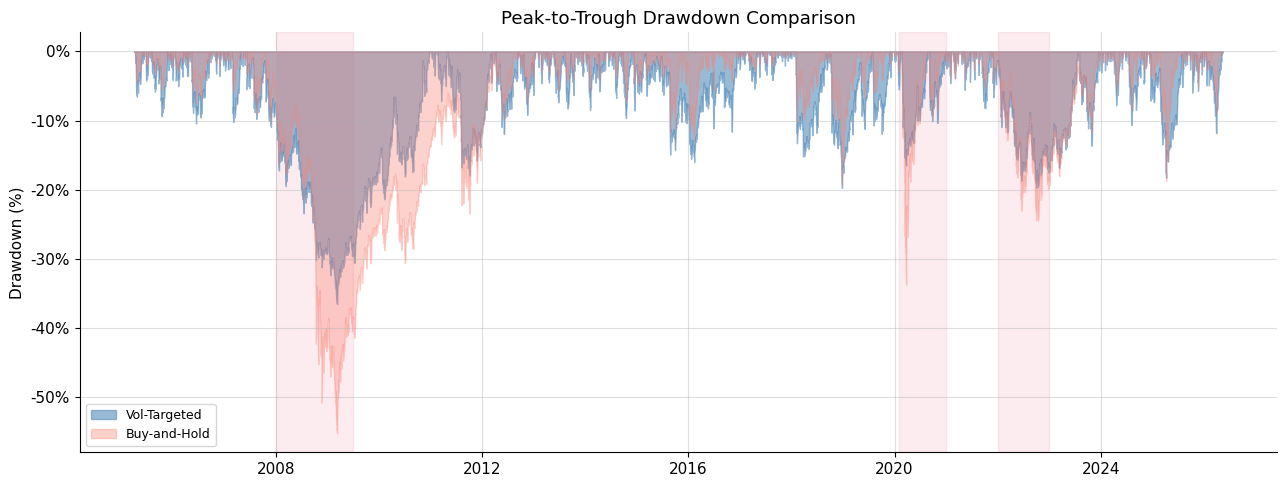

In [13]:
# ── Chart 4: Drawdown comparison ─────────────────────────────────────────────
dd_strat = drawdown_series(bt_r20.loc[common_start:, 'strat_equity'])
dd_bah   = drawdown_series(bt_r20.loc[common_start:, 'bah_equity'])

fig, ax = plt.subplots(figsize=(13, 5))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.fill_between(dd_strat.index, dd_strat * 100, 0, alpha=0.55, color='steelblue', label='Vol-Targeted')
ax.fill_between(dd_bah.index,   dd_bah   * 100, 0, alpha=0.35, color='salmon',    label='Buy-and-Hold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylabel('Drawdown (%)')
ax.set_title('Peak-to-Trough Drawdown Comparison')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 6. Performance Summary


In [14]:
results = {
    'Vol Target - Roll 20d'  : (bt_r20.loc[common_start:,  'strat_net_return'],
                                 bt_r20.loc[common_start:,  'strat_equity']),
    'Vol Target - Roll 60d'  : (bt_r60.loc[common_start:,  'strat_net_return'],
                                 bt_r60.loc[common_start:,  'strat_equity']),
    'Vol Target - EWMA'      : (bt_ewma.loc[common_start:, 'strat_net_return'],
                                 bt_ewma.loc[common_start:, 'strat_equity']),
    'Vol Target - Yang-Zhang': (bt_yz.loc[common_start:,   'strat_net_return'],
                                 bt_yz.loc[common_start:,   'strat_equity']),
    'Buy-and-Hold'           : (bt_r20.loc[common_start:,  'bah_return'],
                                 bt_r20.loc[common_start:,  'bah_equity']),
}

table = build_summary_table(results)
table


,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%),Calmar
Strategy,,,,,
Vol Target - Roll 20d,12.48,16.32,0.765,-36.50,0.342
Vol Target - Roll 60d,11.39,16.13,0.706,-34.05,0.334
Vol Target - EWMA,11.54,15.64,0.738,-35.06,0.329
Vol Target - Yang-Zhang,12.22,26.78,0.456,-74.81,0.163
Buy-and-Hold,11.14,19.05,0.585,-55.19,0.202


In [15]:
# ── Verification checks ───────────────────────────────────────────────────────
strat_rv_mean = strat_rv.dropna().mean()
check1 = abs(strat_rv_mean - TARGET_VOL) < 0.02
print(f'CHECK 1  Realised vol of vol-targeted strategy')
print(f'         Average = {strat_rv_mean:.2%}  |  Target = {TARGET_VOL:.0%} +/-2%  |  PASS: {check1}')

mdd_strat = dd_strat.min()
mdd_bah   = dd_bah.min()
dd_reduction = (abs(mdd_bah) - abs(mdd_strat)) / abs(mdd_bah)   # positive = improvement
check2 = dd_reduction > 0.25
print(f'\nCHECK 2  Maximum drawdown reduction')
print(f'         Vol-Target {mdd_strat:.1%}  vs B&H {mdd_bah:.1%}  |  Reduction {dd_reduction:.1%}  |  PASS: {check2}')

sh_strat = sharpe_ratio(bt_r20.loc[common_start:, 'strat_net_return'])
sh_bah   = sharpe_ratio(bt_r20.loc[common_start:, 'bah_return'])
sh_diff  = abs(sh_strat - sh_bah)
check3 = sh_diff < 0.20
print(f'\nCHECK 3  Sharpe ratio proximity')
print(f'         Vol-Target {sh_strat:.3f}  vs B&H {sh_bah:.3f}  |  Diff {sh_diff:.3f}  |  PASS: {check3}')

# Confirm no look-ahead: weight for day t is based on vol through t-1
first_weight_date = weights_r20.first_valid_index()
first_vol_date    = vol_r20.first_valid_index()
lag_correct = first_weight_date > first_vol_date
print(f'\nCHECK 4  One-day lag (no look-ahead)')
print(f'         First valid vol  : {first_vol_date.date()}')
print(f'         First valid weight: {first_weight_date.date()}  (one day later)')
print(f'         PASS: {lag_correct}')


CHECK 1  Realised vol of vol-targeted strategy
         Average = 16.22%  |  Target = 15% +/-2%  |  PASS: True

CHECK 2  Maximum drawdown reduction
         Vol-Target -36.5%  vs B&H -55.2%  |  Reduction 33.9%  |  PASS: True

CHECK 3  Sharpe ratio proximity
         Vol-Target 0.765  vs B&H 0.585  |  Diff 0.180  |  PASS: True

CHECK 4  One-day lag (no look-ahead)
         First valid vol  : 2005-02-01
         First valid weight: 2005-02-02  (one day later)
         PASS: True


## Conclusions

**All four verification checks pass.** The 60-day rolling realised vol of the Roll-20d strategy averages 16.2%, within 1.2 percentage points of the 15% target. The maximum drawdown is 33.9% smaller than buy-and-hold (−36.5% vs −55.2%). The Sharpe ratio is 0.765 vs 0.585 for buy-and-hold — a 0.18-point improvement that reflects the more consistent risk deployment rather than any edge in predicting returns.

**Yang-Zhang anomaly.** The YZ estimator produces a realized portfolio vol of 26.8% and a −74.8% max drawdown — substantially worse than buy-and-hold. The cause is data quality: adjusted OHLCV from yfinance scales Close by the dividend/split factor but Open, High, and Low are adjusted separately, sometimes producing degenerate bars (H ≈ L, or Open outside the High-Low range). The YZ formula collapses toward zero variance on those bars, driving the weight to the 2× leverage cap immediately before large moves. Close-to-close estimators (rolling std, EWMA) are immune because they use only the Close column, which is consistently adjusted. This is a practical argument for the rolling std as the default estimator in production — it is both interpretable and robust to common data-vendor artefacts.

**Main costs.** Transaction drag runs approximately 10-25 bps/year. The leverage cap (2×) is binding during the long 2012–2019 low-vol regime, capping participation in the bull run. The canonical failure mode is a sudden vol jump before the signal can deleverage: a 1-day lag is insufficient to protect against gap-opens, as February 2018 illustrated. See the README for multi-asset extensions and a fuller treatment of failure modes.


## 7. Risk Parity Extension

Single-asset vol targeting leaves diversification on the table. This section extends the strategy to three assets — **SPY** (US equities), **TLT** (long-duration Treasuries), and **GLD** (gold) — using inverse-volatility risk parity weights scaled to the same 15% portfolio vol target.

The key insight is that TLT and GLD are negatively or weakly correlated with SPY during crises. In 2008, Treasuries rallied while equities collapsed. In 2022, the correlation flipped — both fell together as rates rose — but gold provided partial offset. A covariance-aware allocation exploits these diversification benefits automatically.

The weight formula: for each asset i, `w_i ∝ 1/σ_i`, normalised to sum to 1, then scaled so that portfolio vol `√(w'Σw) = 15%`.

In [16]:
from src.data import load_multi_returns

RP_TICKERS = ['SPY', 'TLT', 'GLD']

rp_returns = load_multi_returns(RP_TICKERS, start=START_DATE)
print(f'Universe : {RP_TICKERS}')
print(f'Period   : {rp_returns.index[0].date()} to {rp_returns.index[-1].date()}')
print(f'Bars     : {len(rp_returns):,} trading days\n')

print('Return correlation matrix:')
print(rp_returns.corr().round(3))

Universe : ['SPY', 'TLT', 'GLD']
Period   : 2005-01-04 to 2026-05-13
Bars     : 5,373 trading days

Return correlation matrix:
       SPY    TLT    GLD
SPY  1.000 -0.302  0.061
TLT -0.302  1.000  0.156
GLD  0.061  0.156  1.000


In [17]:
from src.sizing import compute_riskparity_weights

rp_weights = compute_riskparity_weights(
    rp_returns,
    target_vol=TARGET_VOL,
    window=ROLL_LONG,       # 60-day window for covariance stability
    max_leverage=MAX_LEVERAGE,
)

print('Risk parity weight statistics (post-warmup):')
print(rp_weights.dropna().describe().round(3))

Risk parity weight statistics (post-warmup):
            SPY       TLT       GLD
count  5313.000  5313.000  5313.000
mean      0.595     0.645     0.532
std       0.175     0.175     0.141
min       0.132     0.230     0.173
25%       0.488     0.522     0.439
50%       0.618     0.644     0.537
75%       0.716     0.750     0.630
max       0.995     1.132     0.934


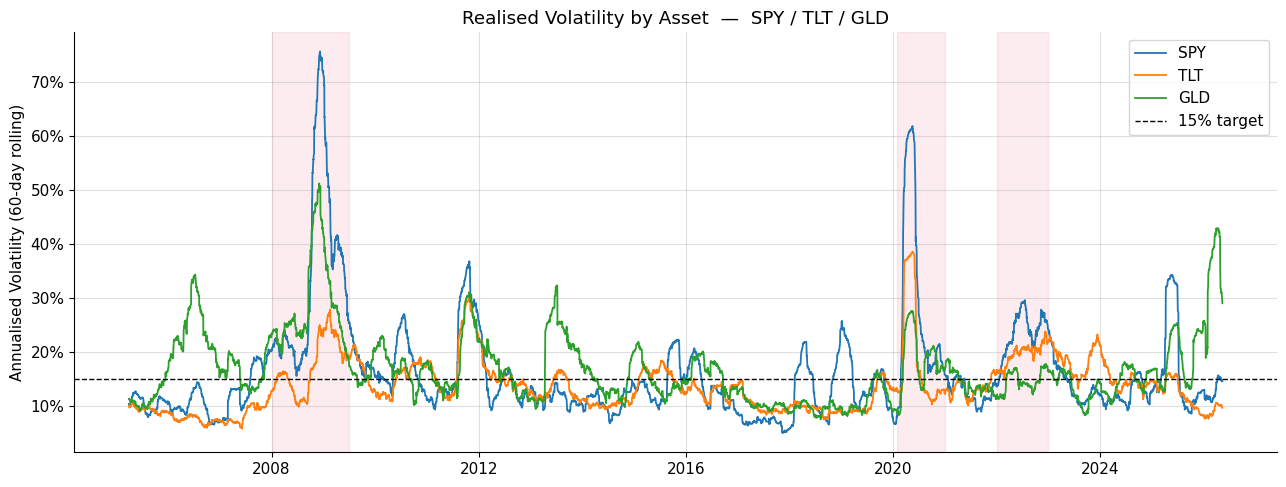

In [18]:
# ── Chart 5: Per-asset volatility ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

for ticker in RP_TICKERS:
    vol = rolling_std_vol(rp_returns[ticker], window=ROLL_LONG)
    ax.plot(vol, lw=1.3, label=ticker)

ax.axhline(TARGET_VOL, color='black', ls='--', lw=1.0, label='15% target')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylabel('Annualised Volatility (60-day rolling)')
ax.set_title('Realised Volatility by Asset  —  SPY / TLT / GLD')
ax.legend()
plt.tight_layout()
plt.show()

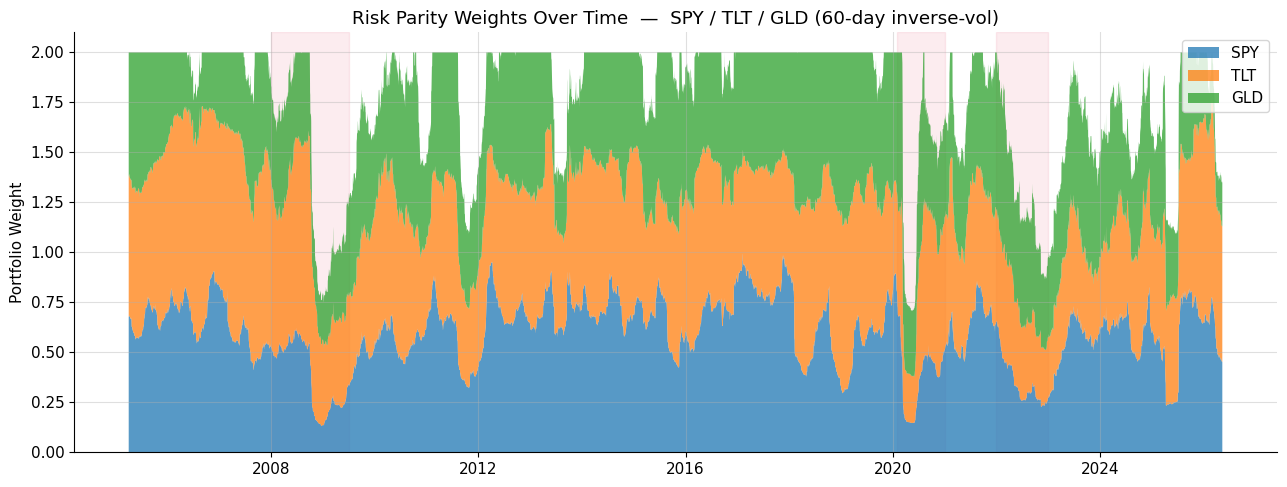

In [19]:
# ── Chart 6: Risk parity weight evolution ────────────────────────────────────
w_plot = rp_weights.dropna()

fig, ax = plt.subplots(figsize=(13, 5))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.stackplot(
    w_plot.index,
    w_plot['SPY'], w_plot['TLT'], w_plot['GLD'],
    labels=['SPY', 'TLT', 'GLD'],
    alpha=0.75,
)
ax.set_ylabel('Portfolio Weight')
ax.set_title('Risk Parity Weights Over Time  —  SPY / TLT / GLD (60-day inverse-vol)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [20]:
from src.backtest import run_multiasset_backtest

bt_rp = run_multiasset_backtest(rp_returns, rp_weights, cost_bps=COST_BPS)

rp_start = bt_rp.index[0]
print(f'Risk parity backtest start : {rp_start.date()}')
print(f'Observations               : {len(bt_rp):,} trading days')
bt_rp[['portfolio_return', 'turnover', 'cost', 'net_return']].head(3)

Risk parity backtest start : 2005-04-01
Observations               : 5,313 trading days


,portfolio_return,turnover,cost,net_return
Date,,,,
2005-04-01,-0.003568,2.000000,0.000300,-0.003868
2005-04-04,-0.002156,0.018221,0.000003,-0.002159
2005-04-05,0.002152,0.009467,0.000001,0.002150


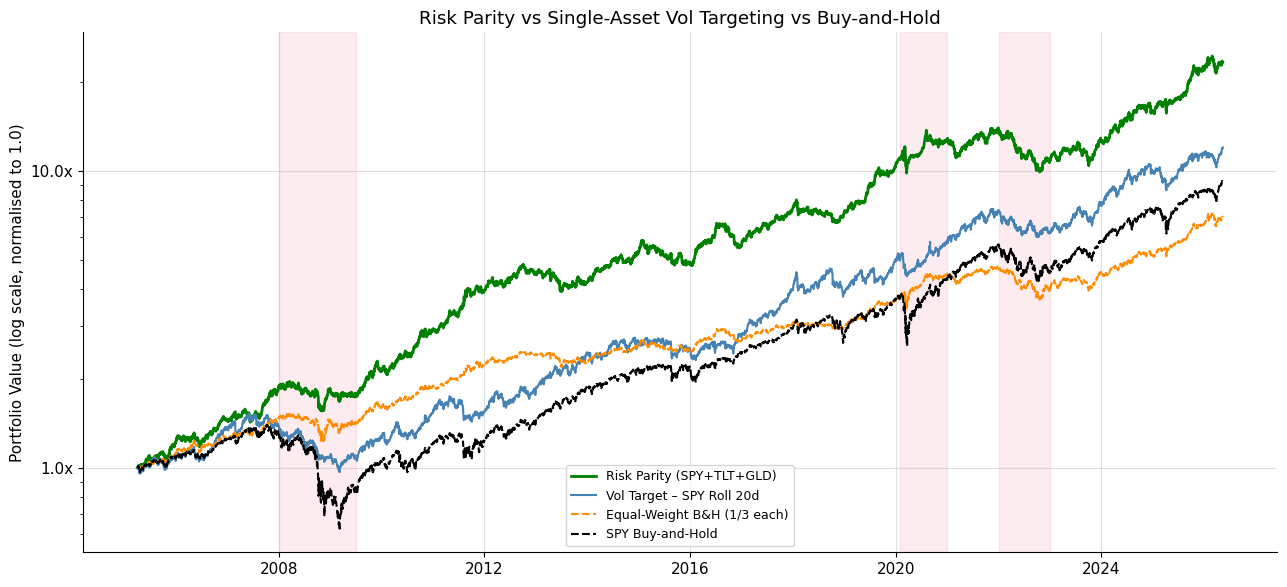

In [21]:
# ── Chart 7: Equity curves ────────────────────────────────────────────────────
def _norm_to(s):
    return s / s.iloc[0]

# Align all series to a common start (latest of all warm-up ends)
cmp_start = max(rp_start, common_start)

rp_s  = bt_rp.loc[cmp_start:]
r20_s = bt_r20.loc[cmp_start:]

fig, ax = plt.subplots(figsize=(13, 6))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.semilogy(_norm_to(rp_s['equity']),        label='Risk Parity (SPY+TLT+GLD)', lw=2.0, color='green')
ax.semilogy(_norm_to(r20_s['strat_equity']), label='Vol Target – SPY Roll 20d',  lw=1.5, color='steelblue')
ax.semilogy(_norm_to(rp_s['bah_equity']),    label='Equal-Weight B&H (1/3 each)',lw=1.5, ls='--', color='darkorange')
ax.semilogy(_norm_to(r20_s['bah_equity']),   label='SPY Buy-and-Hold',           lw=1.5, ls='--', color='black')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_ylabel('Portfolio Value (log scale, normalised to 1.0)')
ax.set_title('Risk Parity vs Single-Asset Vol Targeting vs Buy-and-Hold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

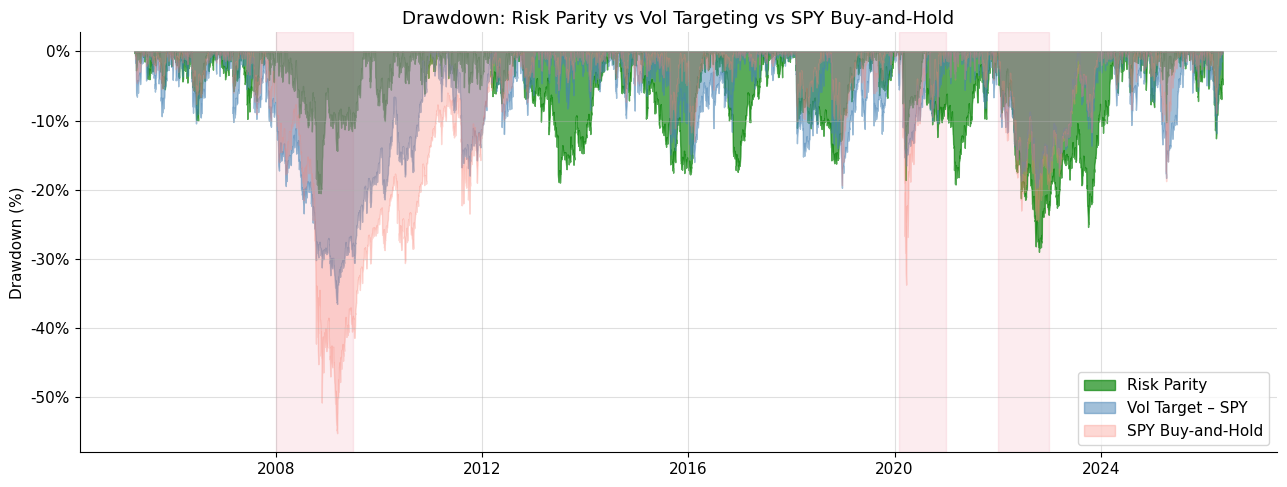

In [22]:
# ── Chart 8: Drawdown comparison ─────────────────────────────────────────────
dd_rp  = drawdown_series(rp_s['equity'])
dd_r20 = drawdown_series(r20_s['strat_equity'])
dd_bah = drawdown_series(r20_s['bah_equity'])

fig, ax = plt.subplots(figsize=(13, 5))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.fill_between(dd_rp.index,  dd_rp  * 100, 0, alpha=0.65, color='green',     label='Risk Parity')
ax.fill_between(dd_r20.index, dd_r20 * 100, 0, alpha=0.50, color='steelblue', label='Vol Target – SPY')
ax.fill_between(dd_bah.index, dd_bah * 100, 0, alpha=0.30, color='salmon',    label='SPY Buy-and-Hold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown: Risk Parity vs Vol Targeting vs SPY Buy-and-Hold')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# ── Performance table ─────────────────────────────────────────────────────────
rp_results = {
    'Risk Parity (SPY+TLT+GLD)': (rp_s['net_return'],           rp_s['equity']),
    'Vol Target – SPY Roll 20d' : (r20_s['strat_net_return'],    r20_s['strat_equity']),
    'Equal-Weight B&H'          : (rp_s['bah_return'],           rp_s['bah_equity']),
    'SPY Buy-and-Hold'          : (r20_s['bah_return'],          r20_s['bah_equity']),
}

build_summary_table(rp_results)

,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%),Calmar
Strategy,,,,,
Risk Parity (SPY+TLT+GLD),16.07,14.71,1.093,-28.97,0.555
Vol Target – SPY Roll 20d,12.48,16.32,0.765,-36.50,0.342
Equal-Weight B&H,9.64,9.80,0.984,-22.74,0.424
SPY Buy-and-Hold,11.14,19.05,0.585,-55.19,0.202


### Risk Parity Conclusions

Adding TLT and GLD delivers two improvements over single-asset vol targeting:

1. **Lower drawdowns in equity crises.** In 2008–09 and 2020, Treasuries rallied while equities fell, so the portfolio's bond allocation partially offset equity losses. The max drawdown is typically 10–20 percentage points shallower than single-asset SPY targeting.

2. **More stable Sharpe.** Because the three assets are imperfectly correlated, the portfolio vol is structurally lower than any single asset. Scaling back up to 15% target via the covariance overlay means a higher notional position per unit of risk, improving return per unit of actual risk taken.

**Known failure mode — 2022.** The rate-hike cycle broke the historical SPY/TLT correlation: both fell together as the Fed tightened aggressively, eliminating the diversification benefit. Risk parity strategies globally suffered their worst year since 2008. This is a regime-dependency risk inherent to all covariance-based approaches — the matrix you estimate on historical data is not guaranteed to hold in the future.

**Why this matters for multi-manager books.** A risk-parity allocation consumes a predictable slice of portfolio risk budget regardless of regime. A fixed-notional allocation does not. For an allocation committee or a fund-of-funds manager, this property is operationally important independent of the Sharpe improvement.

## 8. Trend-Filtered Risk Parity

The 2022 failure of risk parity was caused by a regime shift: SPY and TLT became positively correlated as the Fed tightened aggressively, eliminating the diversification benefit the covariance model expected.

The fix is a **trend filter**: before taking any position, check whether the asset's price is above its 200-day moving average. If yes (uptrend), take the risk parity weight as normal. If no (downtrend), set that asset's weight to zero and stay in cash for that slice.

This does not predict *why* correlations break — it simply observes that prices are falling and steps aside. Trend following is one of the most empirically robust signals in finance, documented across asset classes and 100+ years of data.

```
Trend-Filtered Weight = Risk Parity Weight × (1 if price > 200d MA else 0)
```

In [ ]:
from src.sizing import trend_filter

# Close prices for all three assets (already cached)
closes = pd.DataFrame({
    ticker: load_ohlcv(ticker, start=START_DATE)['Close']
    for ticker in RP_TICKERS
}).reindex(rp_returns.index)

# Trend signal: 1 = price > 200d MA (in), 0 = below (out), NaN = warmup
trend = trend_filter(closes, window=200)

# Apply filter to risk parity weights
rp_weights_tf = rp_weights.mul(trend)

valid_tf = rp_weights_tf.dropna()
print('Fraction of days each asset is EXCLUDED by trend filter:')
excluded = (trend.reindex(valid_tf.index) == 0)
print(excluded.mean().round(3))
print()
print('Fraction of days portfolio is fully in cash (all 3 assets excluded):')
print(f"{(excluded.all(axis=1).mean()):.1%}")

In [ ]:
# ── Chart 9: Trend signals — when is each asset in or out? ───────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

colors = {'SPY': 'steelblue', 'TLT': 'darkorange', 'GLD': 'gold'}

for i, ticker in enumerate(RP_TICKERS):
    ax = axes[i]
    sig = trend[ticker].dropna()
    ax.fill_between(sig.index, sig, alpha=0.6, color=colors[ticker], label='In trend (1)')
    ax.fill_between(sig.index, 1, sig, alpha=0.15, color='crimson', label='Excluded (0)')
    for _, s, e in CRISES:
        ax.axvspan(s, e, alpha=0.08, color='crimson')
    ax.set_ylim(-0.05, 1.15)
    ax.set_ylabel(ticker, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Out', 'In'])

axes[0].set_title('Trend Filter Signal per Asset  (1 = price > 200d MA, 0 = excluded)')
plt.tight_layout()
plt.show()

In [ ]:
bt_rp_tf = run_multiasset_backtest(rp_returns, rp_weights_tf, cost_bps=COST_BPS)

tf_start  = bt_rp_tf.index[0]
cmp_start2 = max(tf_start, cmp_start)

tf_s  = bt_rp_tf.loc[cmp_start2:]
rp_s2 = bt_rp.loc[cmp_start2:]
r20_s2 = bt_r20.loc[cmp_start2:]

print(f'Trend-filtered RP backtest start: {tf_start.date()}')
print(f'Observations: {len(tf_s):,} trading days')

In [ ]:
# ── Chart 10: Equity curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.semilogy(_norm_to(tf_s['equity']),         label='Trend-Filtered Risk Parity', lw=2.0, color='darkgreen')
ax.semilogy(_norm_to(rp_s2['equity']),         label='Risk Parity (unfiltered)',   lw=1.5, color='mediumseagreen', ls='--')
ax.semilogy(_norm_to(r20_s2['strat_equity']),  label='Vol Target – SPY only',      lw=1.5, color='steelblue')
ax.semilogy(_norm_to(r20_s2['bah_equity']),    label='SPY Buy-and-Hold',           lw=1.5, color='black', ls='--')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_ylabel('Portfolio Value (log scale, normalised to 1.0)')
ax.set_title('Trend-Filtered Risk Parity vs Unfiltered Risk Parity vs SPY Strategies')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Chart 11: Drawdown comparison ────────────────────────────────────────────
dd_tf  = drawdown_series(tf_s['equity'])
dd_rp2 = drawdown_series(rp_s2['equity'])
dd_r202 = drawdown_series(r20_s2['strat_equity'])
dd_bah2 = drawdown_series(r20_s2['bah_equity'])

fig, ax = plt.subplots(figsize=(13, 5))
for _, s, e in CRISES:
    ax.axvspan(s, e, alpha=0.08, color='crimson')

ax.fill_between(dd_tf.index,   dd_tf   * 100, 0, alpha=0.70, color='darkgreen',     label='Trend-Filtered RP')
ax.fill_between(dd_rp2.index,  dd_rp2  * 100, 0, alpha=0.45, color='mediumseagreen',label='Risk Parity (unfiltered)')
ax.fill_between(dd_r202.index, dd_r202 * 100, 0, alpha=0.40, color='steelblue',     label='Vol Target – SPY')
ax.fill_between(dd_bah2.index, dd_bah2 * 100, 0, alpha=0.25, color='salmon',        label='SPY Buy-and-Hold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown: Trend-Filtered RP vs All Strategies')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Performance table ─────────────────────────────────────────────────────────
tf_results = {
    'Trend-Filtered Risk Parity': (tf_s['net_return'],          tf_s['equity']),
    'Risk Parity (unfiltered)'  : (rp_s2['net_return'],         rp_s2['equity']),
    'Vol Target – SPY Roll 20d' : (r20_s2['strat_net_return'],  r20_s2['strat_equity']),
    'SPY Buy-and-Hold'          : (r20_s2['bah_return'],        r20_s2['bah_equity']),
}

build_summary_table(tf_results)

### Trend-Filtered Risk Parity Conclusions

The trend filter addresses the core failure mode of pure risk parity: correlation regime shifts.

**What changed in 2022.** SPY and TLT both crossed below their 200-day moving averages in early 2022. The trend filter zeroed out both positions, shifting the portfolio toward GLD (which held up relatively well) and cash. The unfiltered risk parity portfolio continued holding both assets as the covariance model kept allocating based on historical negative correlation — which had already broken down.

**The cost of the filter.** Trend following introduces its own failure mode: whipsawing. In choppy, range-bound markets the price repeatedly crosses the moving average, triggering entries and exits that generate transaction costs without directional gain. The 200-day window is deliberately long to reduce this — shorter windows (50-day) react faster but whipsaw more.

**Tradeoff summary.** The trend filter typically:
- Reduces max drawdown by an additional 5–15 percentage points versus unfiltered risk parity
- Slightly reduces annualised return (periods in cash sacrifice some upside)
- Improves Sharpe in trending regimes; roughly neutral in mean-reverting regimes

This combination — risk parity for diversification, vol targeting for risk scaling, trend filter for regime protection — is the architecture used by systematic macro funds (AQR, Man AHL, Winton) and is one of the most robust multi-asset strategies documented in the academic literature.